<a href="https://colab.research.google.com/github/qjpbtuzara-ai/CPE311-CPE22S3/blob/main/Tuzara_HOA14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tuzara, John Paul B. <br>
Course & Section: CPE311 - CPE22S3 <br>
Date: 4/16/26 <br>
Instructor: Engr. Neal Barton James Matira

##Step 1
* We need to find out how people perform while using AI at work in order to see if AI has a positive net effect on people's jobs

##Step 2
* Do people feel at risk about the role of AI usage in terms of their adjustments felt, such as productivity, salary and upskilling.

##Step 3
* The data can be found in Kaggle. Where 2000 employed people are surveyed.
https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector/data



#Supplementary
1. Map out your datasets to your described objective.
* I have succesfully mapped out the dataset along with ETL to generate 5 graphs fron the dataset.
2. Link and cite all your data.
* https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector/data
3. What do you aim to prove with your dataset and visualization?
* On step 1, I aim to find if AI has a net positive change on jobs.
4. What is the narrative you want to write based on your data?
* I want to write that based on the evidence, the "AI bubble" is becoming less and less and will soon be totally integrated to every economic sector.

In [2]:
#Extract

import pandas as pd

df = pd.read_csv('ai_job_impact.csv')

df

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31


In [9]:
#Transform

text_cols = df.select_dtypes(include=['object']).columns #remove whitespaces
for col in text_cols:
    df[col] = df[col].str.strip()

#seperate to age groups
groups = [20, 30, 40, 50, 60]
range = ['20-29', '30-39','40-49','50-59']
df["Age_Group"] = pd.cut(df['Age'], bins=groups , labels=range, right=False)

#percent difference on salary
df['Salary_Percent_Diff'] = (df['Salary_After_AI'] - df['Salary_Before_AI'])/df['Salary_Before_AI'] * 100


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%,Age_Group,Salary_Percent_Diff
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,50-59,-10.639393
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,40-49,-2.857104
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,50-59,19.764379
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,40-49,-5.815965
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,20-29,20.817350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67,50-59,2.026604
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38,30-39,37.907286
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57,40-49,39.852875
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31,40-49,18.467339


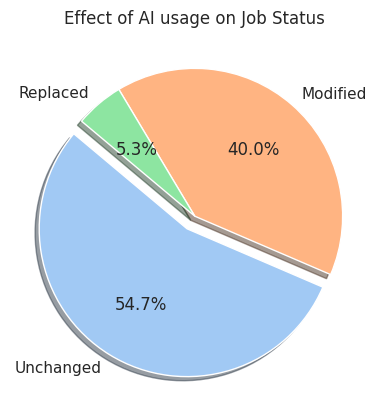

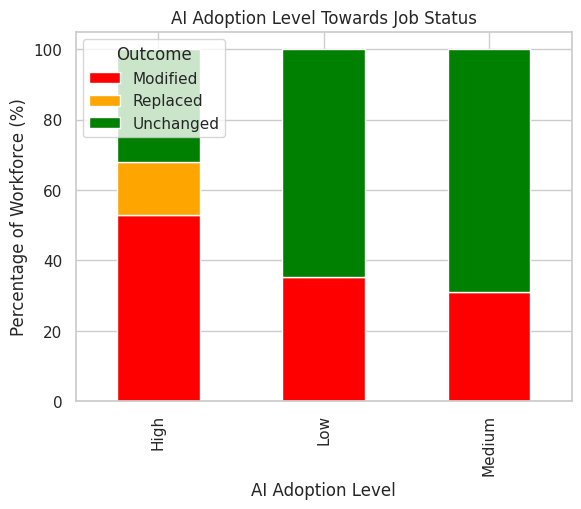

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df['Job_Status'].value_counts()
sns.set_theme(style = "whitegrid")
colors = sns.color_palette('pastel')[0:len(data)]
plt.pie(data,
        labels= data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.1, 0, 0),
        shadow=True
)
plt.title("Effect of AI usage on Job Status")
plt.show()

status = pd.crosstab(df['AI_Adoption_Level'], df['Job_Status'], normalize='index') * 100

status.plot(kind='bar', stacked=True, color=['red', 'orange', 'green'])
plt.title('AI Adoption Level Towards Job Status')
plt.ylabel('Percentage of Workforce (%)')
plt.xlabel('AI Adoption Level')
plt.legend(title='Outcome', loc='upper left')
plt.show()

Data Analysis

I could see that most people who have a high tendency to adopt AI eventually would find their work modified as expected. Nonetheless, most of the status of the status of jobs are mostly unchanged especially when they have a low to medium adoption status.

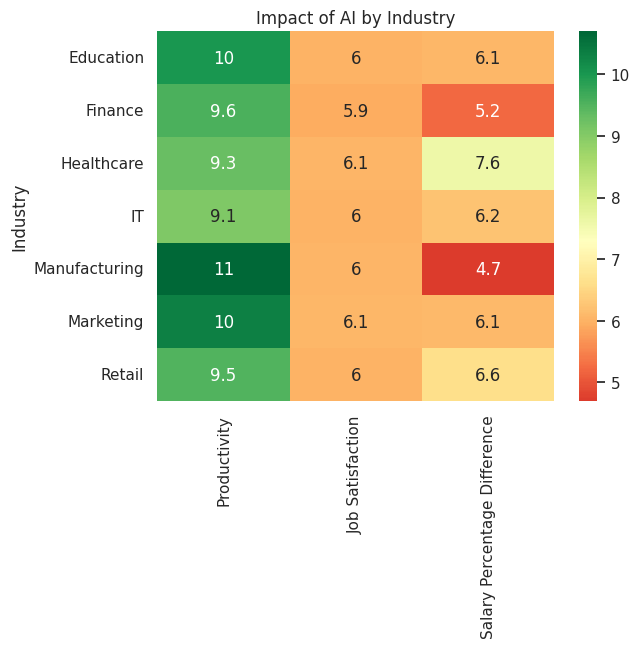

In [33]:
summary = df.groupby('Industry').agg({
    'Productivity_Change_%': 'mean',
    'Job_Satisfaction': 'mean',
    'Salary_Percent_Diff': 'mean'
}).rename(columns={'Productivity_Change_%': 'Productivity',
                   'Job_Satisfaction' : 'Job Satisfaction',
                   'Salary_Percent_Diff':'Salary Percentage Difference'})

sns.heatmap(summary, annot=True, cmap='RdYlGn', center=summary.stack().mean())
plt.title('Impact of AI by Industry')
plt.show()

Data Analysis

The heat map indicates that manufacturing has the hughest productivity among jobs with AI integration although having the lowest increase in salary. This suggest their workers are being aided by AI through automation but since most of their jobs are already automated before AI went big, they dont necessarily pass that profit. In contrast, AI in healthcare has the highest boosted salary and therefore are very satisfied at 6.1 on average.

/tmp/ipykernel_7947/3619280734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_satisfaction = df.groupby('Age_Group')['Job_Satisfaction'].mean().reset_index()
/tmp/ipykernel_7947/3619280734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_satisfaction, x='Age_Group', y='Job_Satisfaction', palette='magma')


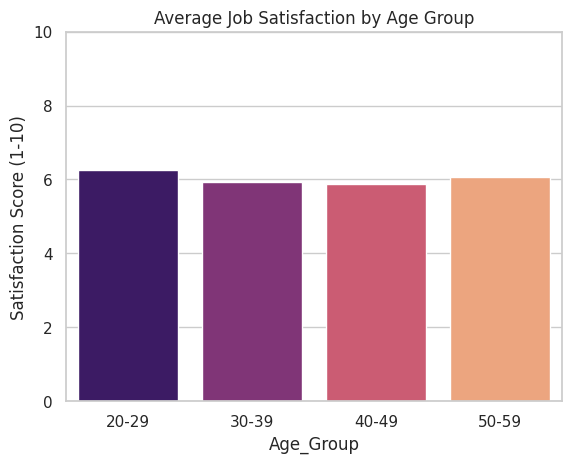

In [30]:
age_satisfaction = df.groupby('Age_Group')['Job_Satisfaction'].mean().reset_index()

sns.barplot(data=age_satisfaction, x='Age_Group', y='Job_Satisfaction', palette='magma')
plt.title('Average Job Satisfaction by Age Group')
plt.ylabel('Satisfaction Score from 1 to 10')
plt.ylim(0, 10)
plt.show()

Data Analysis
It seems that the younger generations have a higher satisfaction overall in AI use along with the generation aged 50-59 compared to 40-49. Suggesting extremes on age have a relationship on AI integration on their jobs.

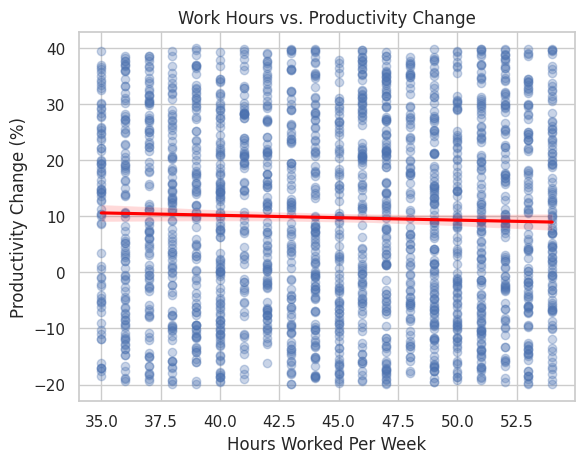

In [31]:
sns.regplot(
    data=df,
    x='Work_Hours_Per_Week',
    y='Productivity_Change_%',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Work Hours vs. Productivity Change')
plt.xlabel('Hours Worked Per Week')
plt.ylabel('Productivity Change (%)')
plt.show()

Data Analysis

Productivity change with AI seems to have no correlation with weekly hourly work. Which suggests that AI is boosting already existing schedules and tasks in production rather than reducing labor.

/tmp/ipykernel_7947/3004537063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Upskilling_Required', y='Salary_Change_Pct', palette='coolwarm')


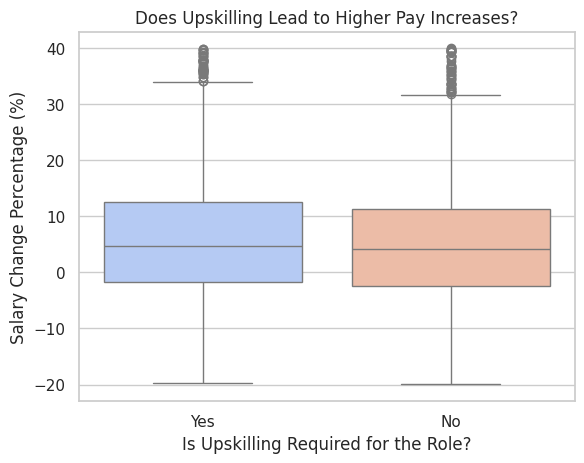

In [32]:
df['Salary_Change_Pct'] = ((df['Salary_After_AI'] - df['Salary_Before_AI']) / df['Salary_Before_AI']) * 100

sns.boxplot(data=df, x='Upskilling_Required', y='Salary_Change_Pct', palette='coolwarm')

plt.title('Does Upskilling Lead to Higher Pay Increases?')
plt.xlabel('Is Upskilling Required for the Role?')
plt.ylabel('Salary Change Percentage (%)')
plt.show()

Data Analysis

There is indeed an indication that people who upskill see a higher average salary growth than people who dont or are not required to. It also suggests that learning new skills is incetivized by employers.

#Conclusions and Analysis

In conclusion, AI does have a positive net effect in a large or macro scale especially in productivity and wages, but the individual has a higher toll or cost in which would be unequal. As I used a heatmap, each industry in the dataset showed an average increase in productivity and salary. The unequal part is that most of the job roles are actually unchanged in which does not necessarily suggest that they are being unaffected but rather are indeed producing value, just not working fewer hours than the rest. And in fact, there seems to be no correlation with AI usage in their change in productivity in hopes of working less hours.This can be seen in the manufacturing heat map as well as their productivity was boosted but have a same relative pay; suggesting there are some stagnation in adapting newer pieces of technology and treatment in some sectors. Nonetheless, people who upskill do in fact recieve more pay to not fall into the unchanged category. The data reinforces the concept of what I have just read about how replacement only happens apparently only when there is high adoption AND high risk.  Suggesting more that AI is a tool of efficiency rather than of equity.

